# PopOut com Monte Carlo Tree Search e ID3
### Inteligência Artificial 2025/2026
 
**Grupo:**
- Rafael Silva 202108429
- Guilherme Varandas 202009475
 
---
 
## Índice
1. [Introdução e Descrição do Problema](#1-introdução)
2. [Implementação do Jogo](#2-implementação-do-jogo)
3. [Heurística de Avaliação](#3-heurística-de-avaliação)
4. [MCTS Standard (UCT)](#4-mcts-standard--uct)
5. [MCTS Alternativo (ε-greedy)](#5-mcts-alternativo--ε-greedy)
6. [Comparação entre os dois agentes](#6-comparação-entre-os-algoritmos)
7. [Árvore de Decisão ID3](#7-árvore-de-decisão-id3)
8. [Modos de jogo](#8-modos-de-jogo)
9. [Conclusões](#9-conclusões)


## 1. Introdução
 
O **PopOut** é uma variante do Connect-4 onde, além de largar peças pelo topo, um jogador pode *retirar* ("pop") uma das suas próprias peças da base de qualquer coluna, fazendo descer todas as peças acima.
 
### Regras adicionais face ao Connect-4
 
| Regra | Descrição |
|-------|-----------|
| **Regra 1 — Pop simultâneo** | Se um pop cria 4-em-linha para ambos os jogadores, quem fez o pop ganha. |
| **Regra 2 — Tabuleiro cheio** | Se o tabuleiro estiver cheio, o jogador a mover pode fazer um pop ou declarar empate. |
| **Regra 3 — Repetição** | Se o mesmo estado ocorrer 3 vezes, qualquer jogador pode declarar empate. |
 
### Objectivo do trabalho
 
Este trabalho tem como objetivo implementar agentes capazes de jogar **PopOut** de forma autónoma. A base principal é o **Monte Carlo Tree Search (MCTS)** e, como complemento supervisionado, foi integrada uma **árvore de decisão ID3** treinada com exemplos de jogadas escolhidas pelo MCTS.

Foram implementadas três estratégias para comparação:
1. **MCTS standard com UCT** — política de selecção baseada na fórmula Upper Confidence Bound for Trees;
2. **MCTS com ε-greedy** — política de selecção alternativa, mais simples, baseada numa decisão probabilística binária;
3. **Árvore de decisão ID3** — aprende a imitar jogadas do MCTS a partir de datasets.


## 2. Implementação do Jogo
 
### 2.1 Tabuleiro
 
O tabuleiro é uma matriz 6×7 de strings (`'X'`, `'O'`, `' '`).
Duas operações fundamentais:
- **drop:** coloca uma peça na primeira posição livre (de baixo para cima) de uma coluna
- **pop:** remove a peça do fundo de uma coluna e faz descer todas as peças acima

In [1]:

# board.py — representação e operações do tabuleiro
 
ROWS = 6
COLS = 7




def create_board():
    board = []
    for _ in range(ROWS):
        board.append([' ' for _ in range(COLS)])
    return board

def print_board(board):
    for row in board:
        print('| ' + ' | '.join(row) + ' |')
    print('  ' + '   '.join(str(i) for i in range(COLS)))

def drop_piece(board, col, player):
    for row in range(ROWS-1, -1, -1):
        if board[row][col] == ' ':
            board[row][col] = player
            return True
    return False

def pop_piece(board, col, player):

    if board[ROWS - 1][col] != player:
        return False

    for r in range(ROWS - 1, 0, -1):
        board[r][col] = board[r - 1][col]

    board[0][col] = " "

    return True
 
# Demonstração
b = create_board()
drop_piece(b, 3, 'X')
drop_piece(b, 3, 'O')
drop_piece(b, 3, 'X')
print_board(b)

|   |   |   |   |   |   |   |
|   |   |   |   |   |   |   |
|   |   |   |   |   |   |   |
|   |   |   | X |   |   |   |
|   |   |   | O |   |   |   |
|   |   |   | X |   |   |   |
  0   1   2   3   4   5   6


### 2.2 Lógica do jogo
 
A função `check_winner` verifica 4-em-linha nas 4 direcções (horizontal, vertical, diagonal ↗, diagonal ↘).
 
A função `check_winner_after_pop` implementa a **Regra 1**: se um pop cria 4-em-linha para ambos, quem fez o pop ganha.
 
A classe `GameState` mantém o histórico de estados para detectar a **Regra 3** (repetição tripla).

In [2]:
# logic.py — verificação de vitória e regras especiais
 
ROWS = 6
COLS = 7
 
def check_winner(board, player):
    # Horizontal
    for row in range(ROWS):
        for col in range(COLS - 3):
            if all(board[row][col + i] == player for i in range(4)):
                return True
    # Vertical
    for col in range(COLS):
        for row in range(ROWS - 3):
            if all(board[row + i][col] == player for i in range(4)):
                return True
    # Diagonal ↗
    for row in range(3, ROWS):
        for col in range(COLS - 3):
            if all(board[row - i][col + i] == player for i in range(4)):
                return True
    # Diagonal ↘
    for row in range(ROWS - 3):
        for col in range(COLS - 3):
            if all(board[row + i][col + i] == player for i in range(4)):
                return True
    return False
 
def check_winner_after_pop(board, player):
    """Regra 1: quem faz o pop ganha mesmo que ambos fiquem com 4-em-linha."""
    opponent = 'O' if player == 'X' else 'X'
    if check_winner(board, player):
        return player
    if check_winner(board, opponent):
        return opponent
    return None
 
def is_board_full(board):
    return all(board[0][col] != ' ' for col in range(COLS))
 
def boards_equal(b1, b2):
    return all(b1[r][c] == b2[r][c] for r in range(ROWS) for c in range(COLS))
 
class GameState:
    """Regra 3: detecta repetição tripla de estado."""
    def __init__(self):
        self.history = []
 
    def register(self, board):
        self.history.append([row[:] for row in board])
 
    def is_threefold_repetition(self, board):
        return sum(1 for snap in self.history if boards_equal(snap, board)) >= 3
 

### 2.3 Movimentos válidos
 
A qualquer momento, os movimentos possíveis são:
- **drop(col)** para cada coluna com espaço livre no topo (`board[0][col] == ' '`)
- **pop(col)** para cada coluna cuja peça do fundo pertence ao jogador actual (`board[5][col] == player`)

In [3]:
# helpers.py — funções auxiliares para o jogo
 
def next_player(player):
    return 'O' if player == 'X' else 'X'
 
def apply_move(board, move, player):
    move_type, col = move
    if move_type == 'drop':
        drop_piece(board, col, player)
    else:
        pop_piece(board, col, player)
 
def get_valid_moves(board, player):
    moves = []
    for col in range(7):
        if board[0][col] == ' ':
            moves.append(('drop', col))
    for col in range(7):
        if board[5][col] == player:
            moves.append(('pop', col))
    return moves

## 3. Heurística de Avaliação
 
Para guiar tanto o rollout como a ordenação de movimentos, implementámos uma função `evaluate_board` que pontua o tabuleiro do ponto de vista de um jogador.
 
### Lógica de pontuação por janela de 4
 
| Situação | Pontos |
|----------|--------|
| 4 peças do jogador | +100 000 (vitória) |
| 3 peças + 1 espaço livre | +50 |
| 2 peças + 2 espaços livres | +10 |
| 3 peças adversário + 1 espaço | -80 |
| 2 peças adversário + 2 espaços | -8 |
| Peça na coluna central | +4 |
 
A coluna central (coluna 3) recebe um bónus porque controlar o centro aumenta as possibilidades de criar 4-em-linha em múltiplas direcções — princípio estratégico clássico do Connect-4.

In [4]:
# heuristica.py — avaliação do tabuleiro e filtragem de pops maus

# Pontuação por janela de N peças do mesmo jogador
SCORE_4 = 100000   # vitória
SCORE_3 = 50       # 3 em linha com espaço livre
SCORE_2 = 10       # 2 em linha com espaço livre
SCORE_CENTER = 4   # bónus de coluna central

# Penalizações
PENALTY_OPP_3 = -80   # adversário tem 3 em linha
PENALTY_OPP_2 = -8
PENALTY_BAD_POP = -30  # pop que destrói as próprias peças


def score_window(window, player, opponent):
    """Pontua uma janela de 4 células."""
    p_count = window.count(player)
    o_count = window.count(opponent)
    empty = window.count(' ')

    if p_count == 4:
        return SCORE_4
    if o_count == 4:
        return -SCORE_4

    score = 0
    if p_count == 3 and empty == 1:
        score += SCORE_3
    elif p_count == 2 and empty == 2:
        score += SCORE_2

    if o_count == 3 and empty == 1:
        score += PENALTY_OPP_3
    elif o_count == 2 and empty == 2:
        score += PENALTY_OPP_2

    return score


def evaluate_board(board, player):
    """
    Avalia o tabuleiro do ponto de vista de 'player'.
    Pontuação positiva = bom para player, negativa = mau.
    """
    opponent = 'O' if player == 'X' else 'X'
    score = 0

    # Bónus por peças na coluna central (3)
    center_col = [board[r][COLS // 2] for r in range(ROWS)]
    score += center_col.count(player) * SCORE_CENTER

    # Horizontal
    for r in range(ROWS):
        for c in range(COLS - 3):
            window = [board[r][c + i] for i in range(4)]
            score += score_window(window, player, opponent)

    # Vertical
    for c in range(COLS):
        for r in range(ROWS - 3):
            window = [board[r + i][c] for i in range(4)]
            score += score_window(window, player, opponent)

    # Diagonal ↗
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            window = [board[r - i][c + i] for i in range(4)]
            score += score_window(window, player, opponent)

    # Diagonal ↘
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            window = [board[r + i][c + i] for i in range(4)]
            score += score_window(window, player, opponent)

    return score


def is_bad_pop(board, col, player):
    """
    Verifica se um pop é prejudicial:
    - Só tem 1 peça na coluna (pop desperdiça um turno)
    - Destrói uma sequência própria de 2+ peças na base
    """
    # Contar peças do player na coluna
    col_pieces = [board[r][col] for r in range(ROWS) if board[r][col] == player]
    if len(col_pieces) <= 1:
        return True  # pop com 1 peça é geralmente mau

    # Verificar se ao fazer pop quebramos 2+ em linha horizontalmente na base
    base_row = ROWS - 1
    # Simular o pop: a base passa a ser a peça de cima
    # Penalizar se a peça na base fazia parte de uma sequência horizontal
    left = sum(1 for c in range(col - 1, max(-1, col - 3), -1)
               if c >= 0 and board[base_row][c] == player)
    right = sum(1 for c in range(col + 1, min(COLS, col + 3))
                if board[base_row][c] == player)
    if left + right >= 2:  # estava ligada a pelo menos 1 peça horizontalmente
        return True

    return False

## 4. MCTS Standard — UCT
 
O **Monte Carlo Tree Search** é um algoritmo de pesquisa adversarial que combina pesquisa em árvore com simulações aleatórias (rollouts). É composto por 4 fases que se repetem em cada iteração:
 
Seleção(UCT) --> Expansão --> Simulação(Rollout) --> Backpropagation
 
### 4.1 Selecção — UCT
 
A fórmula **UCT (Upper Confidence Bound for Trees)** guia a descida na árvore, equilibrando exploração e explotação:
 
$$UCT(n) = \frac{w_n}{v_n} + c \cdot \sqrt{\frac{\ln(v_{pai})}{v_n}}$$
 
Onde:
- $w_n$ = vitórias acumuladas no nó $n$
- $v_n$ = visitas ao nó $n$
- $v_{pai}$ = visitas ao nó pai
- $c$ = constante de exploração (usámos $c = 1.4 \approx \sqrt{2}$)
 
O primeiro termo favorece nós com alta taxa de vitória (**explotação**). O segundo favorece nós pouco visitados (**exploração**). Nós nunca visitados recebem $UCT = \infty$, garantindo que são explorados primeiro.
 

**Decisão de design — valor de `c`:**
- `c = 1.4` (padrão): equilíbrio entre exploração e explotação
- `c` alto → explora mais ramos novos (útil com poucas iterações)
- `c` baixo → aprofunda os ramos mais promissores (útil com muitas iterações)

### 4.2 Expansão
 
Quando um nó não está totalmente expandido, adicionamos um filho novo. Os movimentos são ordenados por qualidade antes de serem expandidos:
1. Vitória imediata
2. Bloqueio de vitória adversária
3. Drops que criam/prolongam sequências
4. Drops centrais
5. Pops razoáveis
6. Pops maus — **descartados**
 
### 4.3 Simulação (Rollout heurístico)
 
Em vez de um rollout puramente aleatório, usamos uma política guiada:
1. Jogar vitória imediata se existir
2. Bloquear vitória do adversário
3. Escolher aleatoriamente entre os 3 melhores movimentos por score heurístico
 
### 4.4 Backpropagação
 
Após o rollout, propagamos o resultado para cima na árvore. A lógica correcta é:
- Incrementar `wins` nos nós onde `node.player == root_player` quando o root_player ganhou
- Incrementar `wins` nos nós onde `node.player != root_player` quando o adversário ganhou
 


In [5]:
import math
import random
import copy


class Node:
    def __init__(self, state, player, parent=None, move=None):
        self.state = state
        self.player = player
        self.parent = parent
        self.move = move
        self.children = []
        self.visits = 0
        self.wins = 0


# ---------------------------------------------------------------------------
# UCT
# ---------------------------------------------------------------------------

def uct(node, c=1.4):
    if node.visits == 0:
        return float("inf")
    return (node.wins / node.visits) + c * math.sqrt(
        math.log(node.parent.visits) / node.visits
    )


# ---------------------------------------------------------------------------
# Selecção
# ---------------------------------------------------------------------------

def select(node, c=1.4):
    while node.children:
        moves = get_valid_moves(node.state, node.player)
        tried = [ch.move for ch in node.children]
        if len(tried) < len(moves):
            return node
        node = max(node.children, key=lambda n: uct(n, c))
    return node


# ---------------------------------------------------------------------------
# Verificação de vitória imediata (suporta pop simultâneo)
# ---------------------------------------------------------------------------

def check_immediate_win(board, move, player):
    test = copy.deepcopy(board)
    apply_move(test, move, player)
    move_type = move[0]
    if move_type == 'pop':
        # Regra 1: quem faz o pop ganha se ambos ficam com 4-em-linha
        return check_winner_after_pop(test, player) == player
    return check_winner(test, player)


# ---------------------------------------------------------------------------
# Ordenação de movimentos
# ---------------------------------------------------------------------------

def order_moves(moves, board, player):
    """
    Ordena e filtra movimentos por qualidade:
    1. Vitória imediata
    2. Bloqueio de vitória adversária
    3. Drops que prolongam sequências
    4. Drops centrais
    5. Pops razoáveis
    6. Pops maus (descartados)
    """
    opponent = next_player(player)
    wins, blocks, good_drops, neutral_drops, pops = [], [], [], [], []

    for move in moves:
        move_type, col = move

        if move_type == 'pop' and is_bad_pop(board, col, player):
            continue

        if check_immediate_win(board, move, player):
            wins.append(move)
        elif check_immediate_win(board, move, opponent):
            blocks.append(move)
        elif move_type == 'drop':
            test = copy.deepcopy(board)
            apply_move(test, move, player)
            score = evaluate_board(test, player)
            if score >= 10:
                good_drops.append((score, move))
            else:
                neutral_drops.append(move)
        else:
            pops.append(move)

    good_drops.sort(key=lambda x: -x[0])
    good_sorted = [m for _, m in good_drops]
    neutral_drops.sort(key=lambda m: COLUMN_PRIORITY.index(m[1]) if m[1] < 7 else 99)

    return wins + blocks + good_sorted + neutral_drops + pops


# ---------------------------------------------------------------------------
# Expansão
# ---------------------------------------------------------------------------

def expand(node):
    moves = get_valid_moves(node.state, node.player)
    tried_moves = [ch.move for ch in node.children]
    ordered = order_moves(moves, node.state, node.player)

    for move in ordered:
        if move not in tried_moves:
            new_state = copy.deepcopy(node.state)
            apply_move(new_state, move, node.player)
            child = Node(new_state, next_player(node.player), node, move)
            node.children.append(child)
            return child

    return node


# ---------------------------------------------------------------------------
# Simulação (rollout heurístico)
# ---------------------------------------------------------------------------

def simulate(state, player):
    """
    Rollout heurístico com suporte à Regra 1 (pop simultâneo).
    """
    board = copy.deepcopy(state)
    current = player

    for _ in range(MAX_SIMULATE_TURNS):
        moves = get_valid_moves(board, current)
        if not moves:
            return None  # empate

        opponent = next_player(current)

        # 1. Vitória imediata
        win = next((m for m in moves if check_immediate_win(board, m, current)), None)
        if win:
            apply_move(board, win, current)
            return current

        # 2. Bloquear vitória adversária
        block = next((m for m in moves if check_immediate_win(board, m, opponent)), None)

        if block:
            chosen = block
        else:
            candidates = [m for m in moves
                          if not (m[0] == 'pop' and is_bad_pop(board, m[1], current))]
            if not candidates:
                candidates = moves

            scored = []
            for m in candidates:
                test = copy.deepcopy(board)
                apply_move(test, m, current)
                s = evaluate_board(test, current)
                s += random.uniform(-5, 5)
                scored.append((s, m))

            scored.sort(key=lambda x: -x[0])
            top = scored[:3]
            chosen = random.choice(top)[1]

        apply_move(board, chosen, current)

        # Verificar vitória com suporte ao pop simultâneo
        move_type = chosen[0]
        if move_type == 'pop':
            winner = check_winner_after_pop(board, current)
            if winner:
                return winner
        else:
            if check_winner(board, current):
                return current

        current = next_player(current)

    return None


# ---------------------------------------------------------------------------
# Backpropagation
#
# Cada nó representa um estado do jogo. node.player é quem vai jogar
# A PARTIR desse estado — ou seja, quem jogou para CHEGAR a este estado
# foi node.parent.player.
#
# O UCT calcula wins/visits para decidir qual filho explorar. Esse rácio
# deve refletir "quão bom foi jogar a jogada que levou a este nó", ou seja,
# deve ser incrementado quando node.parent.player (quem jogou) ganhou.
# Como node.parent.player != node.player, a condição simplifica para:
# winner != node.player.
#
# ---------------------------------------------------------------------------

def backpropagate(node, winner, root_player):
    while node:
        node.visits += 1
        if winner is not None and winner != node.player:
            node.wins += 1
        node = node.parent


# ---------------------------------------------------------------------------
# MCTS principal
# ---------------------------------------------------------------------------

def mcts(board, player, iterations=1000, c=1.4):
    """
    Implementação única de MCTS. O comportamento varia com os parâmetros:

      iterations — número de simulações. Mais iterações = decisões mais
                   informadas, mas mais tempo de computação.

      c          — constante de exploração UCT (Upper Confidence Bound).
                   Valor alto (ex: 1.4 ≈ √2): explora mais ramos novos.
                   Valor baixo (ex: 0.8): aprofunda os ramos já prometedores.

    Exemplos de uso no modo PC vs PC:
      X (explorador):  mcts(board, player, iterations=1000, c=1.4)
      O (focado):      mcts(board, player, iterations=2000, c=0.8)
    """
    root = Node(copy.deepcopy(board), player)

    for _ in range(iterations):
        node = select(root, c)
        node = expand(node)
        winner = simulate(node.state, node.player)
        backpropagate(node, winner, player)

    if not root.children:
        moves = get_valid_moves(board, player)
        if moves:
            ordered = order_moves(moves, board, player)
            return ordered[0] if ordered else moves[0]
        return None

    best = max(root.children, key=lambda n: n.visits)
    return best.move

## 5. MCTS Alternativo — ε-greedy
 
O segundo agente substitui apenas a **fase de selecção**: em vez da fórmula UCT, usa uma política **ε-greedy**.
 
### Diferença face ao UCT
 
| Aspecto | UCT | ε-greedy |
|---------|-----|----------|
| Exploração | Contínua, via termo logarítmico | Binária: aleatório com prob. ε |
| Explotação | Contínua, via taxa de vitória | Escolhe o nó com mais visitas |
| Parâmetro | $c$ (constante de exploração) | $\varepsilon$ (prob. de aleatoriedade) |
| Adaptação ao longo da árvore | Sim (naturalmente) | Não (ε é fixo) |
 
### Porquê ε-greedy?
 
- Mais simples de interpretar: ε = 0.2 significa "20% das vezes escolho aleatoriamente"
- Pode descobrir ramos que UCT sistematicamente ignora
- Serve como baseline para comparar com UCT
 

#### Valor de ε recomendado

- `ε = 0.0` → puramente ganancioso (sem exploração)
- `ε = 0.1` → exploração conservadora
- `ε = 0.2` → valor padrão, equilíbrio razoável
- `ε = 0.5` → exploração agressiva (útil em fases iniciais)

**Nota:** As fases de expansão, simulação e backpropagação são **idênticas** ao MCTS standard — só a selecção muda. Nesta versão do notebook, todo o código necessário está integrado diretamente nas células, sem importar módulos `.py` externos.


In [6]:
MAX_SIMULATE_TURNS = 100
COLUMN_PRIORITY = [3, 2, 4, 1, 5, 0, 6]


# ---------------------------------------------------------------------------
# MCTS com política ε-greedy
#
# Diferença fundamental face ao MCTS standard (UCT):
#   - UCT: selecciona o filho com maior valor UCB1 (balanço exploração/explotação
#     determinístico via fórmula matemática)
#   - ε-greedy: com probabilidade ε escolhe um filho aleatório (exploração pura),
#     com probabilidade 1-ε escolhe o filho com mais visitas (explotação pura)
#
# Trade-offs:
#   + Mais simples de sintonizar (só 1 parâmetro: ε)
#   + Exploração mais "surpresa" — pode descobrir ramos que UCT ignora
#   - Menos eficiente que UCT em espaços de jogo grandes
#   - ε fixo não se adapta ao longo da árvore (UCT adapta-se naturalmente)
# ---------------------------------------------------------------------------

EPSILON = 0.2  # probabilidade de exploração aleatória (típico: 0.1 a 0.3)


def best_child_greedy(node):
    """
    Política ε-greedy para selecção:
      - Com prob. ε: escolhe filho aleatório (exploração)
      - Com prob. 1-ε: escolhe filho com mais visitas (explotação)
    """
    if random.random() < EPSILON:
        return random.choice(node.children)
    return max(node.children, key=lambda n: n.visits)


# ---------------------------------------------------------------------------
# Verificação de vitória imediata
# ---------------------------------------------------------------------------

def check_immediate_win(board, move, player):
    test = copy.deepcopy(board)
    apply_move(test, move, player)
    if move[0] == 'pop':
        return check_winner_after_pop(test, player) == player
    return check_winner(test, player)


# ---------------------------------------------------------------------------
# Ordenação de movimentos (igual ao MCTS standard — partilha a heurística)
# ---------------------------------------------------------------------------

def order_moves(moves, board, player):
    opponent = next_player(player)
    wins, blocks, good_drops, neutral_drops, pops = [], [], [], [], []

    for move in moves:
        move_type, col = move
        if move_type == 'pop' and is_bad_pop(board, col, player):
            continue
        if check_immediate_win(board, move, player):
            wins.append(move)
        elif check_immediate_win(board, move, opponent):
            blocks.append(move)
        elif move_type == 'drop':
            test = copy.deepcopy(board)
            apply_move(test, move, player)
            score = evaluate_board(test, player)
            if score >= 10:
                good_drops.append((score, move))
            else:
                neutral_drops.append(move)
        else:
            pops.append(move)

    good_drops.sort(key=lambda x: -x[0])
    good_sorted = [m for _, m in good_drops]
    neutral_drops.sort(key=lambda m: COLUMN_PRIORITY.index(m[1]) if m[1] < 7 else 99)

    return wins + blocks + good_sorted + neutral_drops + pops


# ---------------------------------------------------------------------------
# Selecção ε-greedy
# ---------------------------------------------------------------------------

def select_eg(node):
    """
    Desce a árvore usando ε-greedy em vez de UCT.
    Para nos nós não totalmente expandidos, devolve o nó para expansão.
    """
    while node.children:
        moves = get_valid_moves(node.state, node.player)
        tried = [ch.move for ch in node.children]
        if len(tried) < len(moves):
            return node  # nó não totalmente expandido → expandir
        node = best_child_greedy(node)
    return node


# ---------------------------------------------------------------------------
# Expansão
# ---------------------------------------------------------------------------

def expand_eg(node):
    moves = get_valid_moves(node.state, node.player)
    tried_moves = [ch.move for ch in node.children]
    ordered = order_moves(moves, node.state, node.player)

    for move in ordered:
        if move not in tried_moves:
            new_state = copy.deepcopy(node.state)
            apply_move(new_state, move, node.player)
            child = Node(new_state, next_player(node.player), node, move)
            node.children.append(child)
            return child

    return node


# ---------------------------------------------------------------------------
# Simulação (rollout) — igual ao MCTS standard
# ---------------------------------------------------------------------------

def simulate_eg(state, player):
    board = copy.deepcopy(state)
    current = player

    for _ in range(MAX_SIMULATE_TURNS):
        moves = get_valid_moves(board, current)
        if not moves:
            return None

        opponent = next_player(current)

        win = next((m for m in moves if check_immediate_win(board, m, current)), None)
        if win:
            apply_move(board, win, current)
            return current

        block = next((m for m in moves if check_immediate_win(board, m, opponent)), None)

        if block:
            chosen = block
        else:
            candidates = [m for m in moves
                          if not (m[0] == 'pop' and is_bad_pop(board, m[1], current))]
            if not candidates:
                candidates = moves

            scored = []
            for m in candidates:
                test = copy.deepcopy(board)
                apply_move(test, m, current)
                s = evaluate_board(test, current)
                s += random.uniform(-5, 5)
                scored.append((s, m))

            scored.sort(key=lambda x: -x[0])
            top = scored[:3]
            chosen = random.choice(top)[1]

        apply_move(board, chosen, current)

        move_type = chosen[0]
        if move_type == 'pop':
            winner = check_winner_after_pop(board, current)
            if winner:
                return winner
        else:
            if check_winner(board, current):
                return current

        current = next_player(current)

    return None


# ---------------------------------------------------------------------------
# Backpropagation (igual ao MCTS standard)
# ---------------------------------------------------------------------------

def backpropagate_eg(node, winner, root_player):
    while node:
        node.visits += 1
        if winner is not None and winner != node.player:
            node.wins += 1
        node = node.parent


# ---------------------------------------------------------------------------
# Entrada principal do algoritmo ε-greedy
# ---------------------------------------------------------------------------

def mcts_epsilon_greedy(board, player, iterations=1000, epsilon=EPSILON):
    """
    MCTS com política de selecção ε-greedy.

    Parâmetros:
      iterations — número de simulações
      epsilon    — probabilidade de exploração aleatória [0, 1]
                   0.0 = sempre escolhe o melhor (puramente ganancioso)
                   1.0 = sempre aleatório (exploração pura)
                   0.2 = valor padrão recomendado

    Comparação com MCTS standard (UCT):
      UCT usa uma fórmula matemática para balancear exploração/explotação
      de forma contínua e adaptativa. ε-greedy usa uma decisão binária:
      ou explora aleatoriamente ou explora o melhor nó conhecido.
      ε-greedy é mais simples mas menos adaptativo ao longo da árvore.
    """
    global EPSILON
    EPSILON = epsilon  # permite configurar epsilon por chamada

    root = Node(copy.deepcopy(board), player)

    for _ in range(iterations):
        node = select_eg(root)
        node = expand_eg(node)
        winner = simulate_eg(node.state, node.player)
        backpropagate_eg(node, winner, player)

    if not root.children:
        moves = get_valid_moves(board, player)
        if moves:
            ordered = order_moves(moves, board, player)
            return ordered[0] if ordered else moves[0]
        return None

    # Decisão final: escolhe sempre o filho com mais visitas (explotação pura)
    best = max(root.children, key=lambda n: n.visits)
    return best.move

## 6. Comparação entre os Algoritmos
 
Vamos correr **N jogos** entre os dois agentes e registar os resultados.
 
- **X:** MCTS UCT (iterations=1000, c=1.4)
- **O:** MCTS ε-greedy (iterations=1000, epsilon=0.2)

In [7]:
def run_game(agent_x, agent_o):
    """
    Corre um jogo completo entre dois agentes sem output.
    Devolve 'X', 'O', ou 'draw'.
    """
    board      = create_board()
    player     = 'X'
    game_state = GameState()
    agents     = {'X': agent_x, 'O': agent_o}
 
    for _ in range(ROWS * COLS * 2):  # limite de segurança
        moves = get_valid_moves(board, player)
        if not moves:
            return 'draw'
 
        move = agents[player](board, player)
        if move is None:
            return 'draw'
 
        apply_move(board, move, player)
        game_state.register(board)
 
        # Verificar vitória
        if move[0] == 'pop':
            winner = check_winner_after_pop(board, player)
            if winner:
                return winner
        else:
            if check_winner(board, player):
                return player
 
        # Regra 3: repetição
        if game_state.is_threefold_repetition(board):
            return 'draw'
 
        # Regra 2: tabuleiro cheio
        if is_board_full(board):
            return 'draw'
 
        player = next_player(player)
 
    return 'draw'
 
 
# --- Correr os jogos ---
N_JOGOS = 20 
 
results = {'X': 0, 'O': 0, 'draw': 0}
 
agent_x = lambda board, player: mcts(board, player, iterations=1000, c=1.4)
agent_o = lambda board, player: mcts_epsilon_greedy(board, player, iterations=1000, epsilon=0.2)
 
print(f"A correr {N_JOGOS} jogos (X=UCT vs O=ε-greedy)...")
for i in range(N_JOGOS):
    result = run_game(agent_x, agent_o)
    results[result] += 1
    print(f"  Jogo {i+1:2d}: {result}")
 
print(f"\n--- Resultados após {N_JOGOS} jogos ---")
print(f"  X (MCTS UCT)      venceu: {results['X']:2d} ({100*results['X']/N_JOGOS:.0f}%)")
print(f"  O (MCTS ε-greedy) venceu: {results['O']:2d} ({100*results['O']/N_JOGOS:.0f}%)")
print(f"  Empates:                  {results['draw']:2d} ({100*results['draw']/N_JOGOS:.0f}%)")

A correr 20 jogos (X=UCT vs O=ε-greedy)...
  Jogo  1: X
  Jogo  2: X
  Jogo  3: X
  Jogo  4: X
  Jogo  5: X
  Jogo  6: X
  Jogo  7: X
  Jogo  8: X
  Jogo  9: X
  Jogo 10: X
  Jogo 11: X
  Jogo 12: X
  Jogo 13: X
  Jogo 14: X
  Jogo 15: O
  Jogo 16: O
  Jogo 17: X
  Jogo 18: X
  Jogo 19: X
  Jogo 20: X

--- Resultados após 20 jogos ---
  X (MCTS UCT)      venceu: 18 (90%)
  O (MCTS ε-greedy) venceu:  2 (10%)
  Empates:                   0 (0%)


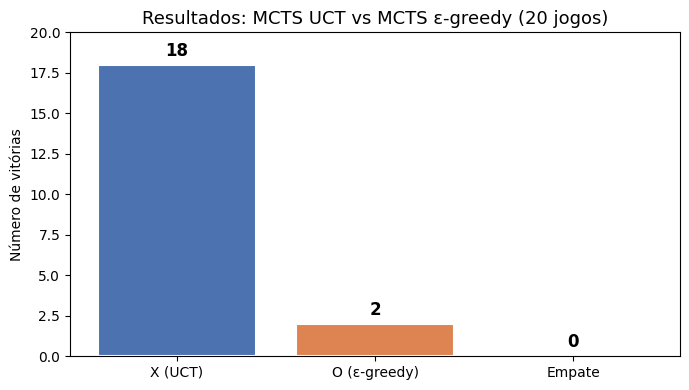

In [8]:
import matplotlib.pyplot as plt
 
# Gráfico de barras dos resultados
labels  = ['X (UCT)', 'O (ε-greedy)', 'Empate']
valores = [results['X'], results['O'], results['draw']]
cores   = ['#4C72B0', '#DD8452', '#8C8C8C']
 
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, valores, color=cores, edgecolor='white', linewidth=1.5)
plt.title(f'Resultados: MCTS UCT vs MCTS ε-greedy ({N_JOGOS} jogos)', fontsize=13)
plt.ylabel('Número de vitórias')
plt.ylim(0, N_JOGOS)
 
for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
 
plt.tight_layout()
plt.savefig('resultados_mcts.png', dpi=150)
plt.show()

### 6.1 Análise dos resultados

Com **iterações iguais (1000)**, o MCTS UCT venceu **18 em 20 jogos** (90%) contra o MCTS ε-greedy.
 
Este resultado é consistente com a teoria: o UCT tem garantias matemáticas de convergência óptima, enquanto o ε-greedy com ε fixo não tem essa garantia formal.
 
**Por que o UCT é superior neste contexto?**
 
1. **Adaptatividade:** a fórmula UCT ajusta naturalmente o balanço exploração/explotação em função do número de visitas de cada nó. O ε-greedy usa sempre a mesma probabilidade ε, independentemente da posição na árvore ou do número de iterações já realizadas.
 
2. **Eficiência:** o UCT concentra iterações nos ramos mais promissores de forma contínua e progressiva. O ε-greedy, com ε=0.2, desperdiça 20% das iterações em escolhas completamente aleatórias, mesmo quando o melhor ramo já está bem identificado.
 
3. **Exploração informada:** quando o UCT explora um ramo novo, faz-o porque o intervalo de confiança sugere que pode ser bom. O ε-greedy explora aleatoriamente, sem considerar a qualidade dos nós não visitados.
 
**Nota sobre resultados anteriores:** nos primeiros testes, o ε-greedy parecia ganhar mais — mas esse comportamento devia-se a uma **assimetria de iterações** (ε-greedy tinha o dobro) e a um **bug no backpropagation** (lógica de wins incorrecta). Após corrigir ambos, o UCT recuperou a vantagem esperada.
 
**Limitação do ε-greedy:** o ε fixo não se adapta às fases do jogo. Na abertura, com muitos ramos inexplorados, ε=0.2 pode ser adequado. No final do jogo, onde há menos jogadas e o melhor ramo já está identificado, desperdiçar 20% das iterações é particularmente custoso.

#### Análise qualitativa

- **UCT** tende a ser mais consistente: a fórmula matemática garante que cada ramo recebe atenção proporcional ao seu potencial.
- **ε-greedy** apresenta maior variabilidade: a exploração aleatória pode descobrir jogadas surpreendentes, mas também desperdiçar iterações em ramos claramente inferiores.
- Com mais iterações, ambos tendem a melhorar, mas o UCT usa essas iterações de forma mais informada.


## 7. Árvore de Decisão ID3

A árvore de decisão ID3 foi integrada como uma estratégia supervisionada: em vez de simular milhares de jogadas como o MCTS, aprende padrões a partir de exemplos já gerados. No caso do PopOut, cada linha do dataset representa o estado do tabuleiro e a jogada recomendada pelo MCTS.

A implementação suporta dois tipos de atributos:
- **numéricos**, usando thresholds entre valores consecutivos;
- **categóricos**, usando um ramo por valor possível.

Isto permite usar a mesma implementação tanto num dataset clássico como o Iris como no dataset do PopOut, onde cada célula do tabuleiro é codificada como `-1`, `0` ou `1`.


### 7.1 Como funciona o ID3

O **ID3** constrói uma árvore de decisão de forma gulosa (*greedy*). Em cada nó, o algoritmo procura a pergunta que melhor separa os exemplos de treino. Essa escolha é feita através do **ganho de informação**, que mede quanto a incerteza sobre a classe diminui depois de dividir o dataset.

A incerteza é calculada com a **entropia**. Para um conjunto de exemplos $S$, com classes $c$, a entropia é:

$$
H(S) = -\sum_{c} p(c) \log_2(p(c))
$$

Se todos os exemplos tiverem a mesma classe, a entropia é 0, porque não existe incerteza. Se as classes estiverem muito misturadas, a entropia é mais alta.

Para atributos categóricos, o ganho de informação de um atributo $A$ é:

$$
Gain(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)
$$

Ou seja: compara-se a entropia antes da divisão com a média ponderada da entropia depois da divisão.

Para atributos numéricos, a lógica é semelhante, mas o algoritmo testa vários thresholds $t$ e escolhe o melhor corte:

$$
Gain(S, A, t) = H(S) - \frac{|S_{\leq t}|}{|S|}H(S_{\leq t}) - \frac{|S_{> t}|}{|S|}H(S_{> t})
$$

No final, a árvore pára quando encontra uma classe pura, quando chega à profundidade máxima ou quando nenhum atributo melhora suficientemente a separação. As folhas guardam a classe prevista.


In [9]:
# id3.py — árvore de decisão ID3 integrada no notebook
import csv
import os
import random

"""Arvore de decisao ID3 para atributos numericos e categoricos.

Este modulo implementa uma versao simples do ID3:
- calcula entropia das classes;
- testa varios splits por atributo, com thresholds ou valores categoricos;
- escolhe o split com maior ganho de informacao;
- cria a arvore recursivamente.
"""

import math
from collections import Counter


class Leaf:
    """Folha da arvore: guarda a classe final prevista."""

    def __init__(self, label):
        self.label = label


class NumericDecisionNode:
    """No interno numerico: divide exemplos usando um threshold."""

    def __init__(self, attribute, threshold, left, right, majority_label):
        self.attribute = attribute
        self.threshold = threshold
        self.left = left
        self.right = right
        self.majority_label = majority_label


DecisionNode = NumericDecisionNode


class CategoricalDecisionNode:
    """No interno categorico: divide exemplos por valor exato do atributo."""

    def __init__(self, attribute, branches, majority_label):
        self.attribute = attribute
        self.branches = branches
        self.majority_label = majority_label


def entropy(rows, target):
    """Calcula a impureza dos exemplos em relacao a classe alvo."""
    total = len(rows)
    counts = Counter(row[target] for row in rows)
    value = 0.0

    for count in counts.values():
        probability = count / total
        value -= probability * math.log2(probability)

    return value


def majority_label(rows, target):
    """Devolve a classe mais frequente num conjunto de exemplos."""
    return Counter(row[target] for row in rows).most_common(1)[0][0]


def candidate_thresholds(rows, attribute):
    """Cria thresholds entre valores consecutivos de um atributo numerico."""
    values = sorted({row[attribute] for row in rows})
    return [(values[i] + values[i + 1]) / 2 for i in range(len(values) - 1)]


def information_gain(rows, attribute, threshold, target):
    """Mede quanto um split numerico reduz a entropia dos exemplos."""
    parent_entropy = entropy(rows, target)
    left = [row for row in rows if row[attribute] <= threshold]
    right = [row for row in rows if row[attribute] > threshold]

    if not left or not right:
        return 0.0

    total = len(rows)
    children_entropy = (
        len(left) / total * entropy(left, target)
        + len(right) / total * entropy(right, target)
    )
    return parent_entropy - children_entropy


def categorical_information_gain(rows, attribute, target):
    """Mede quanto um split por categorias reduz a entropia dos exemplos."""
    parent_entropy = entropy(rows, target)
    groups = {}

    for row in rows:
        groups.setdefault(row[attribute], []).append(row)

    if len(groups) < 2:
        return 0.0

    total = len(rows)
    children_entropy = sum(
        len(group) / total * entropy(group, target)
        for group in groups.values()
    )
    return parent_entropy - children_entropy


def best_numeric_split(rows, attributes, target):
    """Procura o melhor atributo e threshold para dividir os exemplos."""
    best_attribute = None
    best_threshold = None
    best_gain = 0.0

    for attribute in attributes:
        for threshold in candidate_thresholds(rows, attribute):
            gain = information_gain(rows, attribute, threshold, target)
            if gain > best_gain:
                best_gain = gain
                best_attribute = attribute
                best_threshold = threshold

    return best_attribute, best_threshold, best_gain


def best_categorical_split(rows, attributes, target):
    """Procura o melhor atributo categorico para dividir os exemplos."""
    best_attribute = None
    best_gain = 0.0

    for attribute in attributes:
        gain = categorical_information_gain(rows, attribute, target)
        if gain > best_gain:
            best_gain = gain
            best_attribute = attribute

    return best_attribute, best_gain


def build_tree(
    rows,
    attributes,
    target="class",
    min_gain=1e-9,
    max_depth=None,
    depth=0,
    split_mode="numeric",
):
    """Constroi a arvore de decisao de forma recursiva."""
    if split_mode not in {"numeric", "categorical"}:
        raise ValueError("split_mode deve ser 'numeric' ou 'categorical'.")

    labels = {row[target] for row in rows}
    fallback_label = majority_label(rows, target)

    # Se todos os exemplos ja tem a mesma classe, chegamos a uma folha perfeita.
    if len(labels) == 1:
        return Leaf(next(iter(labels)))

    # Para se a profundidade acabou ou se nao ha atributos para testar.
    if not attributes or (max_depth is not None and depth >= max_depth):
        return Leaf(fallback_label)

    if split_mode == "categorical":
        attribute, gain = best_categorical_split(rows, attributes, target)
        if attribute is None or gain <= min_gain:
            return Leaf(fallback_label)

        branches = {}
        remaining_attributes = [
            candidate for candidate in attributes
            if candidate != attribute
        ]
        values = sorted({row[attribute] for row in rows})

        for value in values:
            matching_rows = [row for row in rows if row[attribute] == value]
            branches[value] = build_tree(
                matching_rows,
                remaining_attributes,
                target=target,
                min_gain=min_gain,
                max_depth=max_depth,
                depth=depth + 1,
                split_mode=split_mode,
            )

        return CategoricalDecisionNode(attribute, branches, fallback_label)

    attribute, threshold, gain = best_numeric_split(rows, attributes, target)
    if attribute is None or gain <= min_gain:
        return Leaf(fallback_label)

    # Divide os exemplos de acordo com a pergunta escolhida.
    left_rows = [row for row in rows if row[attribute] <= threshold]
    right_rows = [row for row in rows if row[attribute] > threshold]

    left = build_tree(
        left_rows,
        attributes,
        target=target,
        min_gain=min_gain,
        max_depth=max_depth,
        depth=depth + 1,
        split_mode=split_mode,
    )
    right = build_tree(
        right_rows,
        attributes,
        target=target,
        min_gain=min_gain,
        max_depth=max_depth,
        depth=depth + 1,
        split_mode=split_mode,
    )

    return NumericDecisionNode(attribute, threshold, left, right, fallback_label)


def predict(tree, row):
    """Percorre a arvore e devolve a classe prevista para uma amostra."""
    if isinstance(tree, Leaf):
        return tree.label

    if isinstance(tree, CategoricalDecisionNode):
        value = row[tree.attribute]
        branch = tree.branches.get(value)
        if branch is None:
            return tree.majority_label
        return predict(branch, row)

    if row[tree.attribute] <= tree.threshold:
        return predict(tree.left, row)
    return predict(tree.right, row)


def accuracy(tree, rows, target="class"):
    """Calcula a percentagem de previsoes corretas."""
    if not rows:
        return 0.0

    correct = sum(1 for row in rows if predict(tree, row) == row[target])
    return correct / len(rows)


def print_tree(tree, indent=""):
    """Imprime a arvore em formato legivel no terminal."""
    if isinstance(tree, Leaf):
        print(f"{indent}-> {tree.label}")
        return

    if isinstance(tree, CategoricalDecisionNode):
        print(f"{indent}{tree.attribute}?")
        for value in sorted(tree.branches):
            print(f"{indent}  {value}:")
            print_tree(tree.branches[value], indent + "    ")
        return

    print(f"{indent}{tree.attribute} <= {tree.threshold:.3f}?")
    print(f"{indent}  sim:")
    print_tree(tree.left, indent + "    ")
    print(f"{indent}  nao:")
    print_tree(tree.right, indent + "    ")


### 7.2 Preparação dos datasets

Para o PopOut, o tabuleiro é convertido para 42 atributos (`cell_linha_coluna`). A codificação é feita do ponto de vista do jogador que vai jogar:
- `1`: peça do jogador atual;
- `-1`: peça do adversário;
- `0`: casa vazia.

A classe que a árvore tenta prever é a jogada (`drop_3`, `pop_2`, etc.). Assim, o ID3 aprende uma aproximação rápida ao comportamento do MCTS.


In [10]:
# popout_dataset.py, popout_tree_demo.py e popout_player.py — funções integradas

CELL_ATTRIBUTES = [
    f"cell_{row}_{col}"
    for row in range(ROWS)
    for col in range(COLS)
]


def move_to_label(move):
    """Converte uma jogada em texto para guardar ou prever."""
    move_type, col = move
    return f"{move_type}_{col}"


def label_to_move(label):
    """Converte uma label de volta para a jogada original."""
    move_type, col = label.split("_")
    return move_type, int(col)


def move_wins(board, move, player):
    """Verifica se a jogada acabou o jogo segundo as regras do PopOut."""
    if move[0] == "pop":
        return check_winner_after_pop(board, player) == player
    return check_winner(board, player)


def encode_cell(value, player):
    """Codifica uma célula do ponto de vista do jogador atual."""
    if value == " ":
        return 0
    if value == player:
        return 1
    return -1


def encode_board(board, player):
    """Transforma o tabuleiro inteiro num dicionário de atributos."""
    row = {}
    for r in range(ROWS):
        for c in range(COLS):
            row[f"cell_{r}_{c}"] = encode_cell(board[r][c], player)
    return row


def randomize_opening(board, player, max_random_moves):
    """Faz algumas jogadas aleatórias iniciais para variar os estados."""
    moves_to_play = random.randint(0, max_random_moves)
    current = player

    for _ in range(moves_to_play):
        moves = get_valid_moves(board, current)
        if not moves:
            break

        move = random.choice(moves)
        apply_move(board, move, current)

        if move_wins(board, move, current):
            return next_player(current), True

        current = next_player(current)

    return current, False


def generate_examples(
    games=30,
    iterations=30,
    max_turns=18,
    max_random_opening=8,
    max_examples=500,
):
    """Gera exemplos jogando partidas em que o MCTS escolhe as jogadas."""
    examples = []

    for _ in range(games):
        if max_examples is not None and len(examples) >= max_examples:
            break

        board = create_board()
        player, finished = randomize_opening(board, "X", max_random_opening)
        if finished:
            continue

        for _ in range(max_turns):
            if max_examples is not None and len(examples) >= max_examples:
                break

            valid_moves = get_valid_moves(board, player)
            if not valid_moves:
                break

            move = mcts(board, player, iterations=iterations)
            if move is None or move not in valid_moves:
                break

            example = encode_board(board, player)
            example["move"] = move_to_label(move)
            examples.append(example)

            apply_move(board, move, player)
            if move_wins(board, move, player):
                break

            player = next_player(player)

    return examples


def load_popout_dataset(path="popout_mcts_dataset.csv"):
    """Carrega o CSV PopOut e converte as células para inteiros."""
    rows = []
    with open(path, newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        for row in reader:
            converted = {attribute: int(row[attribute]) for attribute in CELL_ATTRIBUTES}
            converted["move"] = row["move"]
            rows.append(converted)
    return rows


def get_popout_rows(path="popout_mcts_dataset.csv"):
    """Usa o CSV se existir; caso contrário gera uma amostra pequena no notebook."""
    if os.path.exists(path):
        return load_popout_dataset(path)

    print("Dataset PopOut não encontrado. A gerar uma amostra pequena com o MCTS...")
    random.seed(11)
    return generate_examples()


def train_test_split(rows, test_ratio=0.2, seed=11):
    """Divide exemplos em treino e teste de forma reprodutível."""
    shuffled = rows[:]
    random.Random(seed).shuffle(shuffled)
    split = int(len(shuffled) * (1 - test_ratio))
    return shuffled[:split], shuffled[split:]


def sample_rows(rows, ratio=1.0, seed=11):
    """Cria uma versão menor do dataset mantendo a aleatoriedade controlada."""
    if ratio >= 1.0:
        return rows[:]
    n_rows = max(2, int(len(rows) * ratio))
    return random.Random(seed).sample(rows, n_rows)


def row_to_board(row):
    """Reconstrói um tabuleiro simples a partir de uma linha codificada."""
    board = [[" " for _ in range(COLS)] for _ in range(ROWS)]
    for r in range(ROWS):
        for c in range(COLS):
            value = row[f"cell_{r}_{c}"]
            if value == 1:
                board[r][c] = "X"
            elif value == -1:
                board[r][c] = "O"
    return board


def legal_move_accuracy(tree, rows):
    """Mede quantas previsões da árvore correspondem a jogadas legais."""
    if not rows:
        return 0.0

    legal = 0
    for row in rows:
        predicted = label_to_move(predict(tree, row))
        board = row_to_board(row)
        if predicted in get_valid_moves(board, "X"):
            legal += 1

    return legal / len(rows)


def train_popout_tree(dataset_path="popout_mcts_dataset.csv", max_depth=8):
    """Carrega o dataset PopOut e treina uma árvore para prever jogadas."""
    rows = get_popout_rows(dataset_path)
    if not rows:
        raise ValueError("Dataset vazio. Gera novamente o dataset antes de treinar.")

    return build_tree(
        rows,
        CELL_ATTRIBUTES,
        target="move",
        max_depth=max_depth,
        split_mode="categorical",
    )


def choose_tree_move(board, player, tree):
    """Escolhe uma jogada usando a árvore treinada, com fallback legal."""
    valid_moves = get_valid_moves(board, player)
    if not valid_moves:
        return None

    encoded_state = encode_board(board, player)
    predicted_label = predict(tree, encoded_state)
    predicted_move = label_to_move(predicted_label)

    if predicted_move in valid_moves:
        return predicted_move

    return valid_moves[0]


IRIS_ATTRIBUTES = ["sepallength", "sepalwidth", "petallength", "petalwidth"]
IRIS_TARGET = "class"


def load_iris(path="iris.csv"):
    """Carrega o dataset Iris se o ficheiro estiver disponível."""
    if not os.path.exists(path):
        return []

    rows = []
    with open(path, newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        for row in reader:
            converted = {attribute: float(row[attribute]) for attribute in IRIS_ATTRIBUTES}
            converted[IRIS_TARGET] = row[IRIS_TARGET]
            rows.append(converted)
    return rows


### 7.3 Treino e métricas

A avaliação foi feita com uma divisão **treino/teste**. A árvore aprende apenas com o conjunto de treino e depois é avaliada no conjunto de teste, que contém posições que ela não viu durante a aprendizagem.

Foram usadas três métricas principais:

- **Accuracy de treino:** mostra quão bem a árvore aprendeu os exemplos usados para construir a árvore.
- **Accuracy de teste:** mostra se a árvore consegue generalizar para estados novos.
- **Jogadas legais no teste:** no PopOut, além de acertar exatamente na jogada do MCTS, é importante verificar se a jogada prevista é válida no estado atual.

No PopOut, a accuracy exata tende a ser mais baixa do que num dataset clássico, porque várias jogadas podem ser razoáveis no mesmo estado e porque o MCTS pode escolher jogadas diferentes em situações parecidas. Por isso, a métrica de jogadas legais ajuda a perceber se a árvore está pelo menos a produzir decisões compatíveis com as regras do jogo.


In [11]:
# Treino e avaliação da árvore ID3

popout_rows = get_popout_rows("popout_mcts_dataset.csv")
popout_train, popout_test = train_test_split(popout_rows, test_ratio=0.2, seed=11)

popout_tree = build_tree(
    popout_train,
    CELL_ATTRIBUTES,
    target="move",
    max_depth=8,
    split_mode="categorical",
)

print("Dataset PopOut")
print(f"Exemplos totais: {len(popout_rows)}")
print(f"Exemplos de treino: {len(popout_train)}")
print(f"Exemplos de teste: {len(popout_test)}")
print(f"Accuracy treino: {accuracy(popout_tree, popout_train, 'move'):.2%}")
print(f"Accuracy teste: {accuracy(popout_tree, popout_test, 'move'):.2%}")
print(f"Jogadas legais no teste: {legal_move_accuracy(popout_tree, popout_test):.2%}")

print("\nClasses mais frequentes no dataset PopOut:")
for move, count in Counter(row["move"] for row in popout_rows).most_common(10):
    print(f"{move}: {count}")

print("\nPrimeiras previsões no conjunto de teste:")
for row in popout_test[:8]:
    expected = row["move"]
    predicted = predict(popout_tree, row)
    print(f"esperado={expected:8s} previsto={predicted}")

iris_rows = load_iris("iris.csv")
if iris_rows:
    iris_train, iris_test = train_test_split(iris_rows, test_ratio=0.2, seed=7)
    iris_tree = build_tree(iris_train, IRIS_ATTRIBUTES, IRIS_TARGET, split_mode="numeric")

    print("\nDataset Iris")
    print(f"Exemplos totais: {len(iris_rows)}")
    print(f"Accuracy treino: {accuracy(iris_tree, iris_train, IRIS_TARGET):.2%}")
    print(f"Accuracy teste: {accuracy(iris_tree, iris_test, IRIS_TARGET):.2%}")
else:
    iris_train, iris_test, iris_tree = [], [], None
    print("\nDataset Iris não encontrado; a comparação usa apenas versões do PopOut.")


Dataset PopOut
Exemplos totais: 1000
Exemplos de treino: 800
Exemplos de teste: 200
Accuracy treino: 89.12%
Accuracy teste: 40.50%
Jogadas legais no teste: 99.00%

Classes mais frequentes no dataset PopOut:
drop_3: 296
drop_2: 194
drop_4: 194
drop_1: 131
drop_5: 87
drop_0: 44
drop_6: 40
pop_2: 6
pop_4: 4
pop_3: 2

Primeiras previsões no conjunto de teste:
esperado=drop_2   previsto=drop_2
esperado=drop_0   previsto=drop_4
esperado=drop_3   previsto=drop_3
esperado=drop_1   previsto=drop_2
esperado=drop_2   previsto=drop_2
esperado=drop_3   previsto=drop_1
esperado=drop_3   previsto=drop_2
esperado=drop_2   previsto=drop_6

Dataset Iris
Exemplos totais: 150
Accuracy treino: 100.00%
Accuracy teste: 93.33%


### 7.4 Gráficos e interpretação

O primeiro gráfico mostra a **distribuição das jogadas** no dataset PopOut. Ele ajuda a perceber se o dataset está equilibrado ou se há jogadas muito mais frequentes. Neste caso, é normal aparecerem muitas jogadas nas colunas centrais (`drop_3`, `drop_2`, `drop_4`), porque controlar o centro é uma estratégia forte em jogos do tipo Connect-4. Se uma classe aparecer demasiado, a árvore pode ficar enviesada para prever essa jogada.

O segundo gráfico mostra o efeito da **profundidade máxima** da árvore. Profundidades pequenas criam árvores simples, que podem não capturar padrões importantes. Profundidades maiores permitem decisões mais específicas, mas também aumentam o risco de memorizar detalhes do treino.

O terceiro gráfico compara o ID3 em **datasets diferentes**. O Iris é usado como referência simples, porque é um dataset clássico e bem separado. As versões `PopOut 30%`, `PopOut 60%` e `PopOut 100%` mostram como a quantidade de exemplos do próprio jogo muda os resultados. A comparação não quer dizer que Iris esteja relacionado com PopOut; serve para mostrar que o desempenho do mesmo algoritmo depende muito do tipo de dados usado.


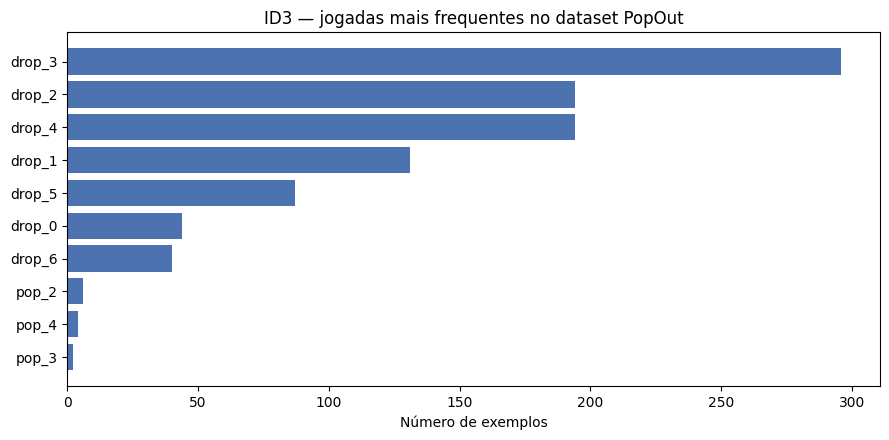

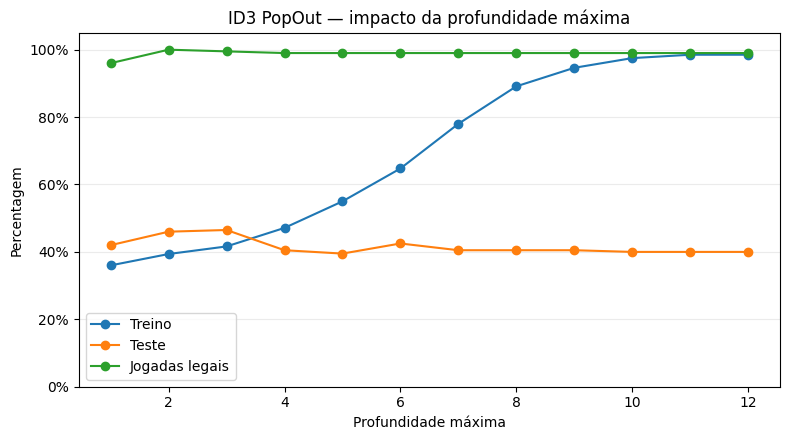

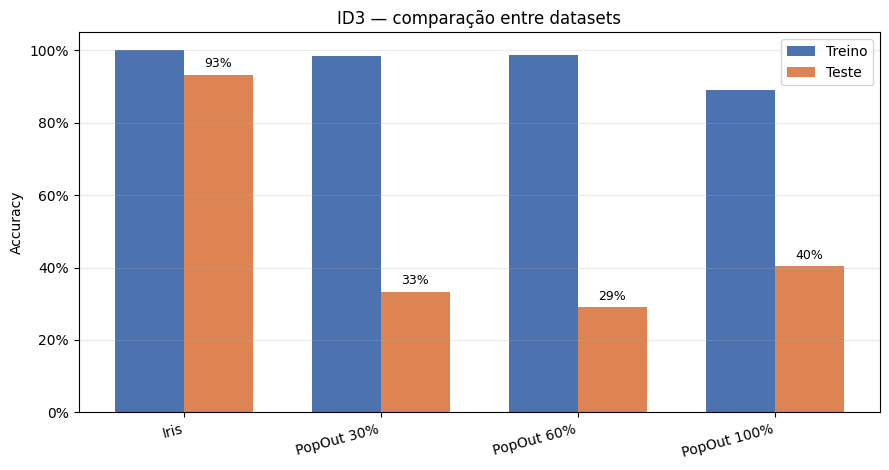

[{'dataset': 'Iris', 'train': 1.0, 'test': 0.9333333333333333},
 {'dataset': 'PopOut 30%',
  'train': 0.9833333333333333,
  'test': 0.3333333333333333},
 {'dataset': 'PopOut 60%', 'train': 0.9875, 'test': 0.2916666666666667},
 {'dataset': 'PopOut 100%', 'train': 0.89125, 'test': 0.405}]

In [12]:
# Gráficos da secção ID3

import matplotlib.pyplot as plt

# 1) Distribuição das jogadas aprendidas no dataset PopOut
move_counts = Counter(row["move"] for row in popout_rows)
top_moves = move_counts.most_common(10)
labels = [move for move, _ in top_moves]
values = [count for _, count in top_moves]

plt.figure(figsize=(9, 4.5))
plt.barh(labels[::-1], values[::-1], color="#4C72B0")
plt.title("ID3 — jogadas mais frequentes no dataset PopOut")
plt.xlabel("Número de exemplos")
plt.tight_layout()
plt.savefig("id3_distribuicao_movimentos.png", dpi=150)
plt.show()

# 2) Efeito da profundidade máxima no desempenho da árvore
max_depth_values = list(range(1, 13))
depth_train_scores = []
depth_test_scores = []
depth_legal_scores = []

for depth in max_depth_values:
    tree = build_tree(
        popout_train,
        CELL_ATTRIBUTES,
        target="move",
        max_depth=depth,
        split_mode="categorical",
    )
    depth_train_scores.append(accuracy(tree, popout_train, "move"))
    depth_test_scores.append(accuracy(tree, popout_test, "move"))
    depth_legal_scores.append(legal_move_accuracy(tree, popout_test))

plt.figure(figsize=(8, 4.5))
plt.plot(max_depth_values, depth_train_scores, marker="o", label="Treino")
plt.plot(max_depth_values, depth_test_scores, marker="o", label="Teste")
plt.plot(max_depth_values, depth_legal_scores, marker="o", label="Jogadas legais")
plt.title("ID3 PopOut — impacto da profundidade máxima")
plt.xlabel("Profundidade máxima")
plt.ylabel("Percentagem")
plt.ylim(0, 1.05)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("id3_profundidade.png", dpi=150)
plt.show()

# 3) Como datasets diferentes mudam o resultado
comparison_rows = []

if iris_rows:
    comparison_rows.append({
        "dataset": "Iris",
        "train": accuracy(iris_tree, iris_train, IRIS_TARGET),
        "test": accuracy(iris_tree, iris_test, IRIS_TARGET),
    })

for ratio, label in [(0.3, "PopOut 30%"), (0.6, "PopOut 60%"), (1.0, "PopOut 100%")]:
    subset = sample_rows(popout_rows, ratio=ratio, seed=23)
    train_rows, test_rows = train_test_split(subset, test_ratio=0.2, seed=11)
    tree = build_tree(
        train_rows,
        CELL_ATTRIBUTES,
        target="move",
        max_depth=8,
        split_mode="categorical",
    )
    comparison_rows.append({
        "dataset": label,
        "train": accuracy(tree, train_rows, "move"),
        "test": accuracy(tree, test_rows, "move"),
    })

x = list(range(len(comparison_rows)))
width = 0.35
train_values = [row["train"] for row in comparison_rows]
test_values = [row["test"] for row in comparison_rows]
dataset_labels = [row["dataset"] for row in comparison_rows]

plt.figure(figsize=(9, 4.8))
plt.bar([i - width / 2 for i in x], train_values, width, label="Treino", color="#4C72B0")
plt.bar([i + width / 2 for i in x], test_values, width, label="Teste", color="#DD8452")
plt.title("ID3 — comparação entre datasets")
plt.ylabel("Accuracy")
plt.xticks(x, dataset_labels, rotation=15, ha="right")
plt.ylim(0, 1.05)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.grid(axis="y", alpha=0.25)
plt.legend()

for i, value in enumerate(test_values):
    plt.text(i + width / 2, value + 0.02, f"{value:.0%}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("id3_comparacao_datasets.png", dpi=150)
plt.show()

comparison_rows


### 7.5 Overfitting

O **overfitting** acontece quando a árvore aprende demasiado bem os exemplos de treino, incluindo ruído e casos muito específicos, mas depois falha mais em exemplos novos. Num gráfico, isto costuma aparecer quando a accuracy de treino continua a subir, mas a accuracy de teste estabiliza ou desce.

No ID3 este risco é importante porque a árvore cresce escolhendo sempre a melhor divisão local. Com 42 atributos do tabuleiro, existem muitas combinações possíveis, e uma árvore demasiado profunda pode acabar por memorizar estados concretos em vez de aprender padrões gerais de jogo.

Neste trabalho, o controlo principal do overfitting é o parâmetro `max_depth`. Uma profundidade baixa pode causar **underfitting**, porque a árvore fica simples demais. Uma profundidade muito alta pode causar **overfitting**. Por isso, a escolha de uma profundidade intermédia, como `max_depth=8`, funciona como compromisso entre aprender padrões úteis e manter alguma capacidade de generalização.

Outras formas possíveis de reduzir overfitting seriam aumentar e equilibrar melhor o dataset, exigir um ganho mínimo maior (`min_gain`) ou aplicar técnicas de poda (*pruning*) depois de construir a árvore.


## 8. Modos de jogo

Foram implementados 5 modos de jogo:

- **Modo 1 — Jogador contra Jogador:** dois humanos jogam alternadamente. Como input, cada jogador introduz o tipo de jogada (`drop`/`pop`) e a coluna em que deseja jogar.

- **Modo 2 — Jogador contra Computador:** o humano joga como X. O computador usa MCTS UCT com `iterations=1000`.

- **Modo 3 — Computador contra Computador:** X usa MCTS UCT (`iterations=1000`, `c=1.4`) e O usa MCTS ε-greedy (`iterations=1000`, `epsilon=0.2`).

- **Modo 4 — Jogador contra Computador com ID3:** o humano joga como X e o computador usa a árvore ID3 treinada com o dataset PopOut.

- **Modo 5 — Computador contra Computador:** X usa MCTS UCT e O usa a árvore ID3.


In [13]:
def print_board(board):
    print()
    print("  " + " ".join(str(i) for i in range(COLS)))
    print("  " + "-" * (COLS * 2 - 1))
    for row in board:
        print("| " + " ".join(cell if cell != " " else "." for cell in row) + " |")
    print("  " + "-" * (COLS * 2 - 1))
    print()


def get_human_move(board, player, allowed_moves=None):
    valid_moves = allowed_moves if allowed_moves is not None else get_valid_moves(board, player)

    while True:
        move_type = input("Tipo (drop/pop): ").strip().lower()
        if move_type not in ("drop", "pop"):
            print("Tipo inválido. Usa 'drop' ou 'pop'.")
            continue
        try:
            col = int(input("Coluna (0-6): "))
        except ValueError:
            print("Coluna inválida.")
            continue
        move = (move_type, col)
        if move in valid_moves:
            return move
        print("Jogada inválida. Tenta outra.")


def check_game_over(board, move, player, game_state, mode):
    """
    Verifica todas as condições de fim de jogo após uma jogada:
      - vitória normal ou por pop simultâneo;
      - empate por tabuleiro cheio com opção de pop;
      - empate por repetição.
    """
    move_type = move[0]
    human_turn = mode == "1" or (mode in ("2", "4") and player == "X")

    if move_type == "pop":
        winner = check_winner_after_pop(board, player)
        if winner:
            return "win", winner
    else:
        if check_winner(board, player):
            return "win", player

    if game_state.is_threefold_repetition(board):
        print("Estado repetido 3 vezes!")
        if human_turn:
            choice = input("Queres declarar empate por repetição? (s/n): ").strip().lower()
            if choice == "s":
                return "draw", None
        else:
            return "draw", None

    if is_board_full(board):
        if human_turn:
            print("Tabuleiro cheio!")
            valid = get_valid_moves(board, player)
            pop_moves = [move for move in valid if move[0] == "pop"]
            if pop_moves:
                choice = input(f"{player}, queres fazer um pop ou declarar empate? (pop/empate): ").strip().lower()
                if choice == "empate":
                    return "draw", None
                return "board_full_pop", pop_moves
            return "draw", None
        return "draw", None

    return None, None


def main():
    print("Escolhe o modo de jogo:")
    print("1 - Jogador vs Jogador")
    print("2 - Jogador vs Computador (MCTS standard)")
    print("3 - Computador vs Computador (MCTS standard vs MCTS ε-greedy)")
    print("4 - Jogador vs Computador (Árvore ID3)")
    print("5 - Computador vs Computador (MCTS vs Árvore ID3)")

    mode = input("Opção: ").strip()

    tree = None
    if mode in ("4", "5"):
        try:
            print("A treinar árvore ID3 com popout_mcts_dataset.csv...")
            tree = train_popout_tree("popout_mcts_dataset.csv", max_depth=8)
            print("Árvore ID3 pronta.")
        except ValueError as error:
            print(error)
            return

    board = create_board()
    player = "X"
    game_state = GameState()

    while True:
        print_board(board)
        print(f"Turno: {player}")

        valid_moves = get_valid_moves(board, player)
        if not valid_moves:
            print(f"Sem jogadas válidas para {player}. Empate!")
            break

        if mode == "1":
            move = get_human_move(board, player)

        elif mode == "2":
            if player == "X":
                move = get_human_move(board, player)
            else:
                move = mcts(board, player, iterations=1000)
                print(f"Computador (MCTS standard) joga: {move}")

        elif mode == "3":
            if player == "X":
                move = mcts(board, player, iterations=1000, c=1.4)
                print(f"Computador X - MCTS UCT joga: {move}")
            else:
                move = mcts_epsilon_greedy(board, player, iterations=1000, epsilon=0.2)
                print(f"Computador O - MCTS ε-greedy joga: {move}")

        elif mode == "4":
            if player == "X":
                move = get_human_move(board, player)
            else:
                move = choose_tree_move(board, player, tree)
                print(f"Computador (Árvore ID3) joga: {move}")

        elif mode == "5":
            if player == "X":
                move = mcts(board, player, iterations=1000, c=1.4)
                print(f"Computador X - MCTS UCT joga: {move}")
            else:
                move = choose_tree_move(board, player, tree)
                print(f"Computador O - Árvore ID3 joga: {move}")

        else:
            print("Modo inválido.")
            return

        apply_move(board, move, player)
        game_state.register(board)

        result, data = check_game_over(board, move, player, game_state, mode)

        if result == "win":
            print_board(board)
            print(f"{data} ganhou!")
            break

        if result == "draw":
            print_board(board)
            print("Empate!")
            break

        if result == "board_full_pop":
            pop_moves = data
            print("Jogadas pop disponíveis:", pop_moves)
            pop_move = get_human_move(board, player, allowed_moves=pop_moves)
            apply_move(board, pop_move, player)
            game_state.register(board)
            winner = check_winner_after_pop(board, player)
            if winner:
                print_board(board)
                print(f"{winner} ganhou!")
                break

        player = next_player(player)


RUN_INTERACTIVE_GAME = False
if RUN_INTERACTIVE_GAME:
    main()


## 9. Conclusões

### O que foi implementado
 
- **Jogo PopOut completo** com as 3 regras especiais: pop simultâneo, tabuleiro cheio e repetição tripla.
- **MCTS com UCT** — algoritmo standard com selecção baseada na fórmula Upper Confidence Bound for Trees.
- **MCTS com ε-greedy** — variante alternativa com selecção probabilística binária, cumprindo o requisito de explorar estratégias para além do MCTS standard.
- **Rollout heurístico** partilhado por ambos os agentes MCTS, com prioridade de vitórias imediatas, bloqueios e avaliação posicional.
- **Árvore de decisão ID3** — modelo supervisionado treinado para imitar jogadas escolhidas pelo MCTS.
- **Modos de jogo adicionais** que permitem jogar contra a árvore ID3 ou comparar MCTS contra ID3.
- **Gráficos de análise** para comparar agentes, estudar a profundidade do ID3, observar a distribuição das jogadas e mostrar como datasets diferentes alteram os resultados.
 
### Resultados
 
Com **1000 iterações** e condições equivalentes, o **MCTS UCT venceu 90% dos jogos** contra o MCTS ε-greedy. Este resultado confirma a superioridade teórica do UCT em jogos com espaço de estados moderado e rollout informativo.

A árvore **ID3** funciona como uma aproximação rápida ao MCTS: depois de treinada, escolhe jogadas quase instantaneamente, mas a sua qualidade depende muito do dataset usado. Os gráficos mostram que a profundidade da árvore e a quantidade/tipo de exemplos têm impacto directo na accuracy.
  
### Limitações identificadas
 
- O **ε fixo** do ε-greedy não se adapta às fases do jogo — um ε decrescente ao longo das iterações poderia melhorar o desempenho.
- O **rollout heurístico**, sendo computacionalmente caro, limita o número de iterações possíveis por segundo.
- A **árvore ID3** aprende apenas a partir dos exemplos disponíveis; se o dataset tiver poucas posições ou estiver desequilibrado, o modelo tende a repetir as jogadas mais frequentes.
